### Import Libraries

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline


### Load Dataset

In [26]:
df = pd.read_csv(r"C:\Users\ANKIT\Downloads\multiple_linear_regression_dataset_realistic.csv")
df.head()


,year,month,interest_rate,unemployment_rate,index_price
0,2022,1,3.77,7.18,1460.79
1,2022,2,4.71,7.86,1307.32
2,2022,3,4.53,6.59,1566.42
3,2022,4,3.92,7.14,1489.66
4,2022,5,4.40,6.69,1467.03


### Basic Info + Missing Values

In [28]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   year               25 non-null     int64  
 1   month              25 non-null     int64  
 2   interest_rate      25 non-null     float64
 3   unemployment_rate  25 non-null     float64
 4   index_price        25 non-null     float64
dtypes: float64(3), int64(2)
memory usage: 1.1 KB


year                 0
month                0
interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

### Drop Unnecessary Columns

In [29]:
df = df.drop(columns=["year", "month"])

### Visualization (relationship check)

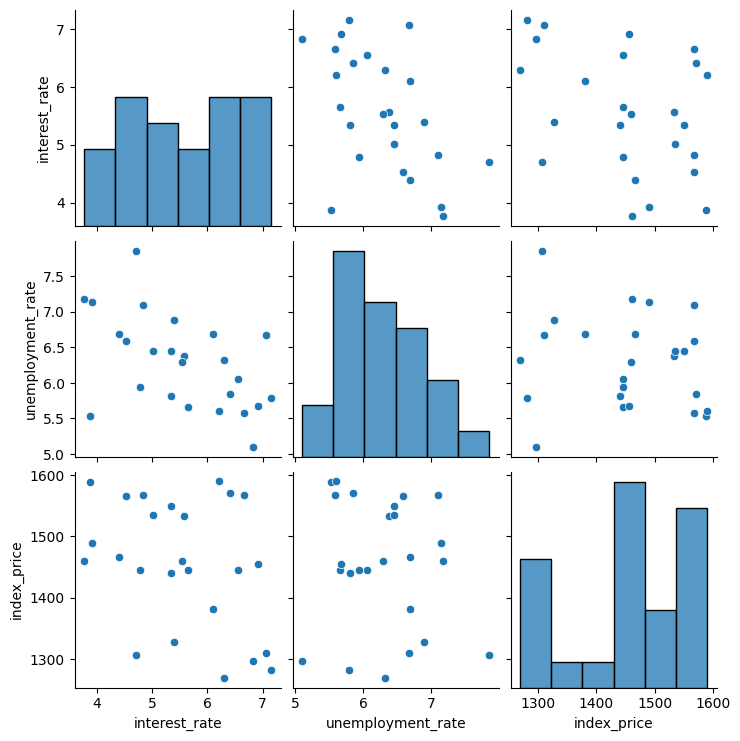

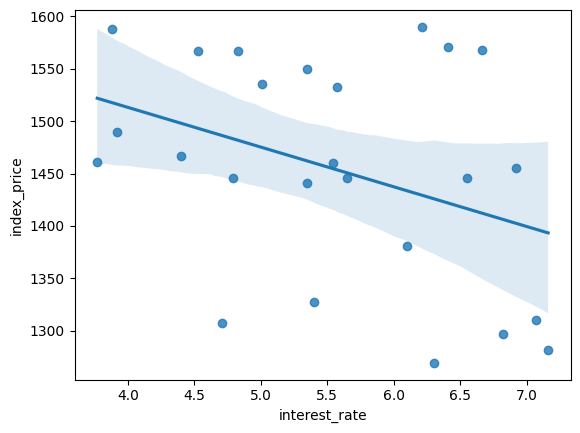

In [30]:
sns.pairplot(df)
plt.show()

sns.regplot(x='interest_rate', y='index_price', data=df)
plt.show()

### Separate Features and Target

In [32]:
X = df[['interest_rate','unemployment_rate']]
y = df['index_price']

### Train-Test Split

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

### Feature Scaling

In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)   # fit + transform
X_test = scaler.transform(X_test)         # only transform

### Train Linear Regression Model

In [35]:
from sklearn.linear_model import LinearRegression

regression = LinearRegression()
regression.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Model Coefficients

In [36]:
print("Coefficients:", regression.coef_)
print("Intercept:", regression.intercept_)

Coefficients: [-49.4800537  -75.30285272]
Intercept: 1456.8616666666667


### Prediction

In [37]:
y_pred = regression.predict(X_test)

### Model Evaluation

In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE) : {mae:.3f}")
print(f"Mean Squared Error (MSE)  : {mse:.3f}")
print(f"Root Mean Squared Error   : {rmse:.3f}")
print(f"R2 Score                  : {r2:.3f}")

Mean Absolute Error (MAE) : 124.107
Mean Squared Error (MSE)  : 19942.392
Root Mean Squared Error   : 141.218
R2 Score                  : -0.697


### Residual Plot

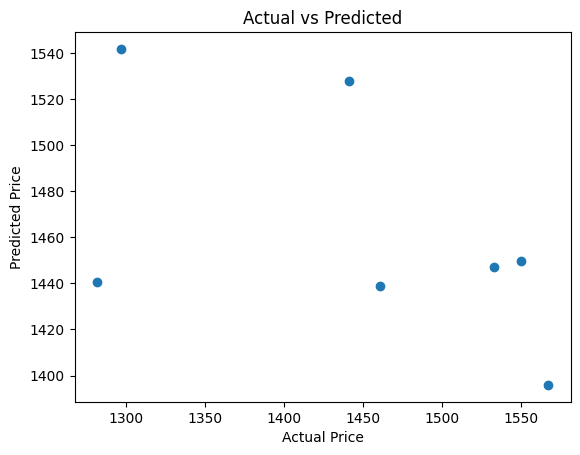

In [39]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

### Cross Validation

In [40]:
from sklearn.model_selection import cross_val_score

validation_score = cross_val_score(
    regression,
    X,
    y,
    scoring="neg_mean_squared_error",
    cv=5
)

mse_scores = -validation_score
rmse_scores = np.sqrt(mse_scores)

print("Cross Validation RMSE Scores:", rmse_scores)
print("Average RMSE:", rmse_scores.mean())


Cross Validation RMSE Scores: [ 86.31475851  98.47012637  59.52764506 108.73869103 122.68608872]
Average RMSE: 95.14746193671628


In [41]:
import statsmodels.api as sm
model = sm.OLS(y_train,X_train).fit()
model.predict()

array([-147.87369357,   53.97976741,  -63.53120273,   16.34883333,
        -73.83435529,   74.44944636,  -20.61188038,   10.57663447,
         34.08111327,    8.94404028, -120.77555728,  -19.14735231,
        -38.52457941,   82.91543714,    9.63316177,    1.65752974,
         13.48117047,  178.23148673])

In [42]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:            index_price   R-squared (uncentered):                   0.003
Model:                            OLS   Adj. R-squared (uncentered):             -0.122
Method:                 Least Squares   F-statistic:                            0.02031
Date:                Mon, 09 Feb 2026   Prob (F-statistic):                       0.980
Time:                        18:37:07   Log-Likelihood:                         -156.67
No. Observations:                  18   AIC:                                      317.3
Df Residuals:                      16   BIC:                                      319.1
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------